In [ ]:
%reset -f
import sys
sys.path.append('/home/sanjith/paper/default_pop/PsrPopPy_2000/psrpoppy')
from psrpoppy import population
import pickle
import sys
import matplotlib.pyplot as plt
import psrpoppy.population as real_population
import pandas as pd
import numpy as np
import multiprocessing
import time
from numba import njit


# Fake the 'population' module name to point to the real one
sys.modules['population'] = real_population
filename='PMSURV_SNR_-10.results'

with open(filename, 'rb') as f:
    pop = pickle.load(f)

# Extract data
fluxes = np.array([psr.s_1400() for psr in pop.population])*10**-26
distances = np.array([psr.dtrue for psr in pop.population])*1e3
luminosities = np.array([psr.lum_1400 for psr in pop.population])
snr = np.array([psr.snr for psr in pop.population])
n_samples = len(fluxes)
print("number of pulsars",n_samples)

# Build DataFrame (read-only)
df = pd.DataFrame({
    'Flux': fluxes,
    'Distance': distances,
    'luminosity':luminosities,
    'snr':snr
})

df_smr = df[df['snr']==-1]

# Save the filtered DataFrame to Excel
df_smr.to_excel("df_smr.xlsx", index=False)
print(len(df_smr))

number of pulsars 229744
56514


number of pulsars 229744
                Flux      Distance         snr
2       4.109254e-29   7418.271416    0.340220
4       4.093381e-29   6770.115336    0.249322
6       6.988890e-31  14837.611782    0.001193
7       1.684376e-30  10334.407362    0.006663
8       1.228404e-30  13491.873125    0.006149
...              ...           ...         ...
229738  6.590731e-30   6900.124556    0.047750
229740  7.873527e-29   8666.075125    0.444286
229741  2.174073e-29  14180.978801    0.162316
229742  3.899249e-30   7657.284657    0.029673
229743  2.338865e-26   4417.275743  214.654795

[130781 rows x 3 columns]
log_flux_cut 2.3028420492100072e-28 -27.6377358490566


/tmp/ipykernel_785/1339216383.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


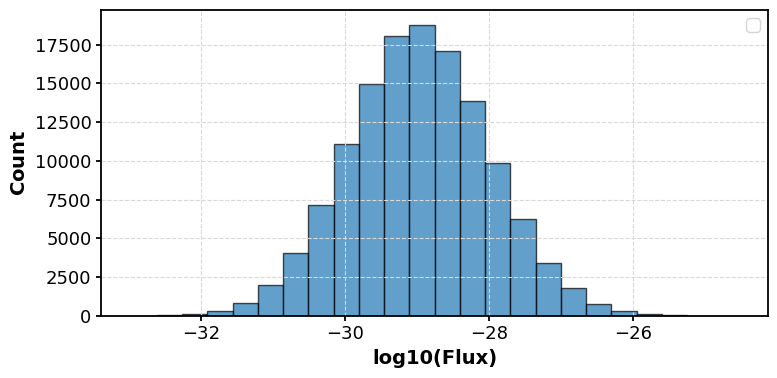

                Flux      Distance         snr
15      3.050391e-28  12899.471170    0.213547
44      5.419743e-27    988.091404   15.456677
55      1.201354e-27   5993.377132    6.282354
64      3.276767e-28   6017.560903    1.594024
79      3.245321e-28   9684.393963    0.354533
...              ...           ...         ...
229704  7.030544e-28   2780.590718    4.942396
229712  2.951676e-28   1570.412545    1.964488
229723  4.473130e-28   5756.403790    1.119747
229727  4.396664e-28   7322.899244    2.340211
229743  2.338865e-26   4417.275743  214.654795

[11296 rows x 3 columns]


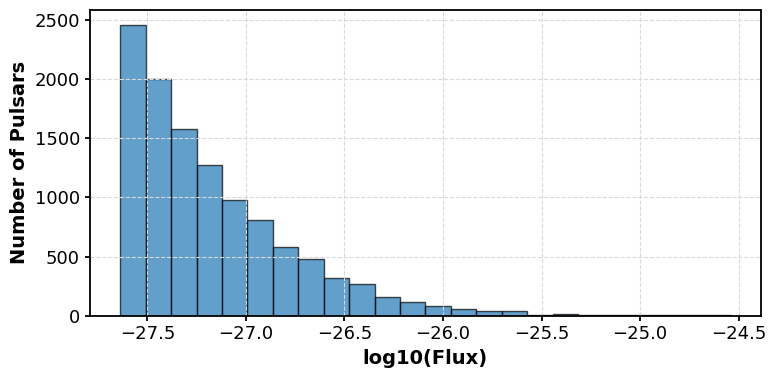


Computing for quantile=a (10%), flux threshold=0.00
Done in 7.4s

Computing for quantile=b (20%), flux threshold=0.00
Done in 3.1s

Computing for quantile=c (30%), flux threshold=0.00
Done in 2.1s

Computing for quantile=d (40%), flux threshold=0.00
Done in 2.0s


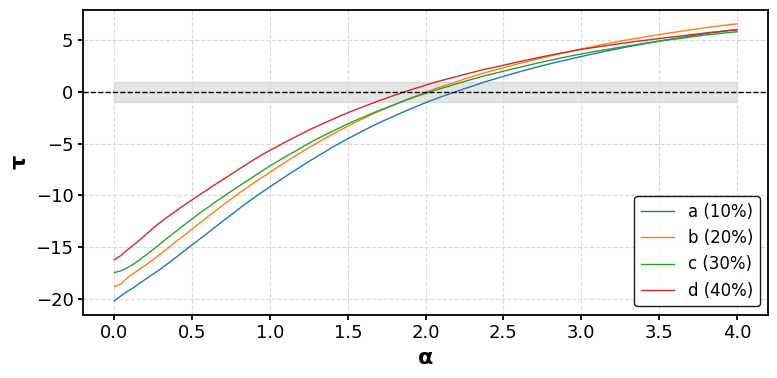

In [ ]:



%reset -f
%matplotlib inline
from psrpoppy import population
import pickle
import sys
import matplotlib.pyplot as plt
import psrpoppy.population as real_population
import pandas as pd
import numpy as np
import multiprocessing
import time
from numba import njit
import matplotlib as mpl
import sys
sys.path.append('/home/sanjith/paper/default_pop/PsrPopPy_2000/psrpoppy')
mpl.rcParams.update({
    "font.size": 14,                # Larger base font
    "axes.labelweight": "bold",
    "axes.titlesize": 16,           # Title font size
    "axes.titleweight": "bold",
    "axes.linewidth": 1.3,          # Thicker axes lines
    "lines.linewidth": 1,         # Thicker plot lines
    "legend.fontsize": 12,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
})
sys.modules['population'] = real_population
filename='PMSURV_SNR_-10.results'

#df_smr = pd.read_excel("df_smr.xlsx")                           ################
#print(df_smr)

with open(filename, 'rb') as f:
    pop = pickle.load(f)

# Extract data
fluxes = np.array([psr.s_1400() for psr in pop.population])*10**-26
distances = np.array([psr.dtrue for psr in pop.population])*1e3
luminosities = np.array([psr.lum_1400 for psr in pop.population])
snr = np.array([psr.snr for psr in pop.population])
n_samples = len(fluxes)
print("number of pulsars",n_samples)

# Build DataFrame (read-only)
df = pd.DataFrame({
    'Flux': fluxes,
    'Distance': distances,
    'snr':snr
})
df=df[df["snr"] >=0]  #selecting only positive snr's
print(df)

#df = pd.concat([df, df_smr], ignore_index=True)                #adding smeared pulsars  to the dataset
log_snr=np.log10(1)
flux_cut=10**((log_snr-29.296)/1.060)

print("log_flux_cut",flux_cut,np.log10(flux_cut))


# ---- Histogram before cut (log scale y) ----
plt.figure(figsize=(8,4))
plt.hist(np.log10(df['Flux'].dropna()), bins=24, alpha=0.7,edgecolor='black', linewidth=1.0)
#plt.axvline(-3.61, color='r', linestyle='--')
#plt.axvline(-2.76, color='r', linestyle='--')
plt.xlabel("log10(Flux)")
plt.ylabel(r"$\mathbf{Count}$")

#plt.title("Histogram of Pulsar Fluxes (Before Cut)")
plt.legend()
plt.tight_layout()
plt.show()




df=df[df['Flux']>=flux_cut]#flux cut
print(df)

# ---- Histogram after cut (log scale y) ----
plt.figure(figsize=(8,4))
plt.hist(np.log10(df['Flux'].dropna()), bins=24, alpha=0.7,edgecolor='black', linewidth=1.0)
#plt.axvline(-3.50, color='r', linestyle='--')
#plt.axvline(-2., color='r', linestyle='--')
plt.xlabel("log10(Flux)")
plt.ylabel("Number of Pulsars")
#plt.title("Histogram of Pulsar Fluxes (After Cut)")
plt.tight_layout()
plt.show()



df['Flux_log'] = np.log10(df['Flux'])
df['Dist_log'] = np.log10(df['Distance'])

def compute_LogLth(D_array, flux_thresh, alpha):
    """Compute log10(flux_thresh * D^alpha)"""
    return np.log10(flux_thresh) + alpha * np.log10(D_array)
plt.figure(figsize=(8,4))
@njit
def compute_tau_numba(D_logs, Lprime_logs, thresh, alpha):
    n = len(D_logs)
    N_a = np.zeros(n, dtype=np.int64)
    R_a = np.zeros(n, dtype=np.int64)
    E_a = np.zeros(n)
    V_a = np.zeros(n)

    for i in range(n):
        Di = D_logs[i]
        Li = Lprime_logs[i]
        L_thi = np.log10(thresh * (10 ** Di) ** alpha)
        N_count = 0
        R_count = 0
        for j in range(n):
            D = D_logs[j]
            L = Lprime_logs[j]
            if (D <= Di) and (L >= L_thi):
                N_count += 1
                if Li >= L:
                    R_count += 1
        N_a[i] = N_count
        R_a[i] = R_count
        E_a[i] = 0.5 * (N_count + 1)
        V_a[i] = (N_count ** 2 - 1) / 12 if N_count > 0 else 0.0

    numerator = np.sum(R_a - E_a)
    denominator = np.sqrt(np.sum(V_a))
    return numerator / denominator if denominator != 0 else np.nan

def compute_tau_for_alpha(alpha_thresh):
    alpha, thresh = alpha_thresh


    LogLthA = compute_LogLth(df['Distance'].values, thresh, alpha)


    Lprime_Log = df['Flux_log'].values + alpha * df['Dist_log'].values


    mask = Lprime_Log >= LogLthA
    D_logs = df['Dist_log'].values[mask]
    Lprime_logs = Lprime_Log[mask]

    if len(D_logs) == 0:
        return alpha, np.nan

    tau = compute_tau_numba(D_logs, Lprime_logs, thresh, alpha)
    return alpha, tau

if __name__ == '__main__':
    #plt.figure(figsize=(8,6))
    quantiles = ['a (10%)', 'b (20%)', 'c (30%)', 'd (40%)']
    quantiles_num =[10,20,30,40]                                                               #no flux threshold removal
    flux_thresholds = np.percentile(df["Flux"],quantiles_num)
    alphas = np.linspace(0,4,100)

    for q, thresh in zip(quantiles, flux_thresholds):
        print(f"\nComputing for quantile={q}, flux threshold={thresh:.2f}")
        start = time.time()

        alpha_thresh_list = [(alpha, thresh) for alpha in alphas]


        with multiprocessing.Pool(processes=4) as pool:
            results = pool.map(compute_tau_for_alpha, alpha_thresh_list)


        results.sort()
        taus = [tau for alpha, tau in results]

        print(f"Done in {time.time() - start:.1f}s")
        plt.plot(alphas, taus, label=f"{q}")

    plt.axhline(0, color='k', linestyle='--')
    plt.xlabel(r'$\mathbf{\alpha}$', fontsize=16)
    plt.ylabel(r'$\mathbf{\tau}$', fontsize=16)

    #plt.title(f'Efron–Petrosian $\\tau$ vs $\\alpha$ rdist=lfl06 psrpoppy {filename[13:-8]}')
   # plt.figtext(0.5, 0.01, f"snr=0.0 dataset with smeared population ,flux cut={flux_cut} corr. to snr=0.01" ,ha="center", fontsize=9, color="gray")
    plt.fill_between(alphas, -1, 1, color='gray', alpha=0.2)
    plt.legend(frameon=True, loc="best", facecolor='white', framealpha=0.9, edgecolor='black')
    #plt.savefig("/mnt/e/pulsar/plots/efron_petrosian_tau_alpha_no smeared_snr_9_lfl06_abcd.pdf", dpi=1000, bbox_inches="tight")
    plt.grid(True,zorder=1)
    plt.tight_layout()
    plt.show()

